In [39]:
from sklearn.linear_model import LogisticRegression
import pandas as pd 
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
import numpy as np

- If the labels are three it internally uses soft_max
- sag and saga we use this when we have more features in sentance based classification

### Important features in logistic regression

1) penalty: Literal['l1', 'l2', 'elasticnet'] | None = "l2"
- By default penalty is l2
- model=LogisticRegression(penalty='l1')
- model=LogisticRegression(penalty='l2')
- model=LogisticRegression(penalty='elasticnet')

2) solver: Literal['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'] = "lbfgs" 
- It is an optimization engine which helps gradient descent to optimize the weights
- The choice of the algorithm depends on the penalty chosen and on (multinomial) multiclass support:

- solver	        |     penalty	                | multinomial multiclass
- 'lbfgs'	        |    'l2', None	                |         yes
- 'liblinear' 	    |    'l1', 'l2'	                |          no
- 'newton-cg'	    |    'l2', None	                |         yes
- 'newton-cholesky' |    'l2', None	                |         yes
- 'sag'	            |    'l2', None	                |         yes
- 'saga'	        |'elasticnet', 'l1', 'l2', None	|         yes

- Hyper parameter tuning : among all the possiblites it gives the best solver for l2

3) max_iter: Int = 100
- It is used to set the max no. iterations based on the size of the dataset
- with the help of tolerance it stops the iterations, so which means it has reached the best weights
- tolerance helps G.D to stop the iteration

4) class_weight: Mapping | str | None = None
- We use class_wright when the dataset is imbalanced 
- Based on target column unique values count we can check the dataset is balanced or imbalanced.
- spam=450, not spam=550  : balanced
- spam=700, not spam=300  : imbalanced
- two techiniques to handle imbalanced dataset :
  - Class_weight='balanced'
  - Re-sampling

5) tol: Float = 0.0001
- with the help of tolerance it stops the iterations, so which means it has reached the best weights
- tolerance helps G.D to stop the iteration

6) C: Float = 1
- It is regularization strength, here we can give few values, it descides wheather the model is going to be underfit, overfit or goodfit
- based on the C value

- It the target column has continous values never use LogisticRegression
- 

In [40]:
df=pd.read_csv('loan_approval_dataset.csv')


In [41]:
X=df.drop(columns='Loan_Approved')
Y=df.Loan_Approved

In [42]:
df.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [43]:
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,train_size=0.8,random_state=42)

In [44]:
num_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns

<Axes: >

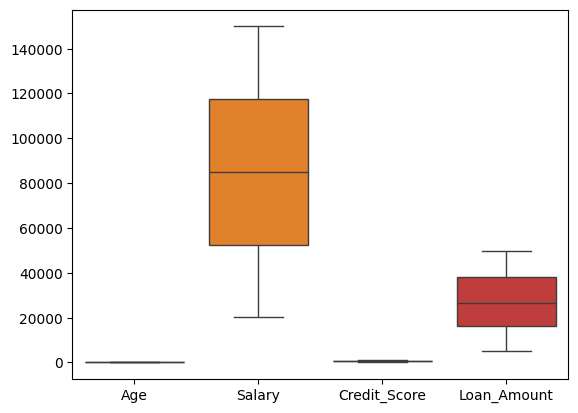

In [45]:
sns.boxplot(df[num_cols])

Why scaling?
- Feature (numerical)cols values are in different range(scale). So we can use Scaling to give equal importance for all  feature cols.

Why encoding?
- Algorithms can understand only numbers not strings

Which scaling technique?
- As we can see in the above box plot there are not outliers present hence we can use normalization technique, i.e MinMaxScaler( )

Which encoding technique?
- Loan_Term            4
- Employment_Status    3
- Residence_Type       3
- Previous_Default     2
- As we have more than one feature column and less unique values so we can use OneHotEnocoder()

In [46]:
X[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

In [47]:
scale=MinMaxScaler()
updated_Xtrain=scale.fit_transform(xtrain[num_cols])
updated_Ytrain=scale.transform(xtest[num_cols])

In [48]:
encode=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
values=encode.fit_transform(xtrain[obj_cols])
cols=encode.get_feature_names_out()

In [49]:
xtrain[cols]=values

In [50]:
xtrain.drop(columns=['Loan_Term','Employment_Status','Residence_Type','Previous_Default'],inplace=True)

In [51]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,44,85441,507,17109,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,38,87298,489,10776,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,45,49629,762,39441,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,47,75337,809,40596,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,46,101121,504,31956,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,52,118723,689,31649,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,26,135654,388,22514,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,64,135005,683,8642,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,26,47856,841,45697,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [52]:
val=encode.transform(xtest[obj_cols])
col=encode.get_feature_names_out()

In [53]:
xtest[col]=val

In [54]:
xtest.drop(columns=['Loan_Term','Employment_Status','Residence_Type','Previous_Default'],inplace=True)
xtest

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
521,25,48769,586,29322,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,38,109431,311,25447,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
740,34,128730,717,34336,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
660,38,60998,821,10355,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
411,61,98757,680,31421,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,54,136243,448,43975,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
332,34,146944,719,47138,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,40,21645,319,6875,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
613,22,90342,734,42291,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [55]:
model=LogisticRegression(max_iter=1000, penalty=None)
model.fit(xtrain,ytrain)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [56]:
model.n_iter_

array([633])

In [57]:
ypred_train=model.predict(xtrain)
ypred_test=model.predict(xtest)

In [58]:
df["Loan_Approved"].value_counts()

Loan_Approved
Yes    508
No     492
Name: count, dtype: int64

- The Data set is balanced

## train data unique value counts

In [59]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

## test data unique value counts

In [60]:
ytest.value_counts()

Loan_Approved
Yes    105
No      95
Name: count, dtype: int64

## 1) Confusion matrix

In [61]:
train_matrix=confusion_matrix(ytrain,ypred_train)

In [62]:
np.sum(train_matrix[:,1])
np.sum(train_matrix[:,0])

375

- Out of 397 actual "No" samples, 204 were correctly classified as "No" (True Negatives), while 193 were incorrectly classified as "Yes" (False Positives).
- Out of 403 actual "Yes" samples, 232 were correctly classified as "Yes" (True Positives), while 171 were incorrectly classified as "No" (False Negatives).

In [63]:
confusion_matrix(ytest,ypred_test)

array([[47, 48],
       [52, 53]], dtype=int64)

- Out of 95 actual "No" samples, 47 were correctly classified as "No" (True Negatives), while 48 were incorrectly classified as "Yes" (False Positives).
- Out of 105 actual "Yes" samples, 53  were correctly classified as "Yes" (True Positives), while 52  were incorrectly classified as "No" (False Negatives).

## 2) Precision Score

***For train data***

In [64]:
print(precision_score(ytrain,ypred_train,pos_label='No'))
print(precision_score(ytrain,ypred_train,pos_label='Yes'))

0.5466666666666666
0.548235294117647


- Out of all predicted "No" labels (375),54% samples are correctly predicted as "No" (True Negatives), while 46% samples were wrongly predicted as "Yes" (False Negatives).
- Out of all predicted "Yes" labels (425), 54% samples are correctly predicted as "Yes"(True Positive) , while 46% samples were wrongly predicted as "No" (False Positive)

***For test data***

In [65]:
print(precision_score(ytest,ypred_test,pos_label='No'))
print(precision_score(ytest,ypred_test,pos_label='Yes'))

0.47474747474747475
0.5247524752475248


- Out of all predicted "No" (99),47% samples are correctly predicted as "No" (True Negatives), while 53% samples were wrongly predicted as "Yes" (False Negatives).
- Out of all predicted "Yes" labels (101), 52% samples are correctly predicted as "Yes"(True Positive) , while 48% samples were wrongly predicted as "No" (False Positive)

## 3) Recall Score

***For train data***

In [66]:
print(recall_score(ytrain,ypred_train,pos_label='No'))
print(recall_score(ytrain,ypred_train,pos_label='Yes'))

0.5163727959697733
0.5781637717121588


- Out of all actual 'No' labels (397), 51% of samples are correctly predicted as 'No' (True Negative), while 49% samples are wrongly predicted as 'Yes' (False Negative)
- Out of all actual 'Yes' labels (403), 57% of samples are correclty predicted as 'Yes' (True Positive), while 43% of samples are wrongly predicted as 'No' (False Negative)

***For test data***

In [67]:
print(recall_score(ytest,ypred_test,pos_label='No'))
print(recall_score(ytest,ypred_test,pos_label='Yes'))

0.49473684210526314
0.5047619047619047


- Out of all actual 'No' lables (95), 49% of samples are correclty predicted as 'No'(True Negative) while 51% of samples are wrongly predicted as 'Yes'(False Negative).
- Out of all actual 'Yes' labels (105), 50% of samples are correclty predicted as 'Yes'(True Negative), while 50% of samples are wrongly predicted as 'No'(False Negative)

## 4) Accuracy Score

- To check the accuracy score we need to first check the data is balanced or imbalanced , because we can use this accuracy_score for only balanced datasets

In [68]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

- As we can see the above target columns labels values has less difference, so the data set is balanced we can use the accuracy score 

In [69]:
accuracy_score(ytrain,ypred_train)

0.5475

- Out of all 800 samples, 54% samples are correclty predcited  and 46% samples are wrongly predicted.

In [70]:
accuracy_score(ytest, ypred_test)

0.5

- Out of all 200 samples, 50% samples are correclty predicted and 50% samples are wrongly predicted.

## 5) f1 Score

- We use this metric when we have imbalanced data set

In [71]:
print(f1_score(ytrain,ypred_train, pos_label='No'))
print(f1_score(ytrain,ypred_train, pos_label='Yes'))

0.5310880829015544
0.5628019323671497


In [72]:
print(f1_score(ytest,ypred_test, pos_label='No'))
print(f1_score(ytest,ypred_test, pos_label='Yes'))

0.4845360824742268
0.5145631067961165


***Conclusion***

- Model performance on train data is bad, so model is not learned train data patterns properly.
- Also model performance on test data is bad, so model is not learned test data patterns properly.
- So here the model is underfit, model is too simple not able to capture the complex patterns

In [73]:
from sklearn.metrics import classification_report
print('Classification_report\n',classification_report(ytrain,ypred_train))

Classification_report
               precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



- Macro it takes the average of metrics & tells overall conclusion of yes and no labels, out of all predicted lables how many predicted correclty, it takes the average of all class labels.
- Weighted uses a metric and support 

In [74]:
print('Classification_report\n',classification_report(ytest,ypred_test))

Classification_report
               precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200

